# Load the data

In [2]:
%run env.ipynb

In [3]:
import pickle
import os
import numpy as np
from jLM.RDME import File as RDMEFile
import jLM
import json
import matplotlib.pyplot as plt
import seaborn as sns
from traj_analysis_rdme import *
from tqdm import tqdm

Processing files:   0%|          | 0/1 [00:00<?, ?file/s]

G2
G2GAE
G2GAI
R2
ribosomeR2


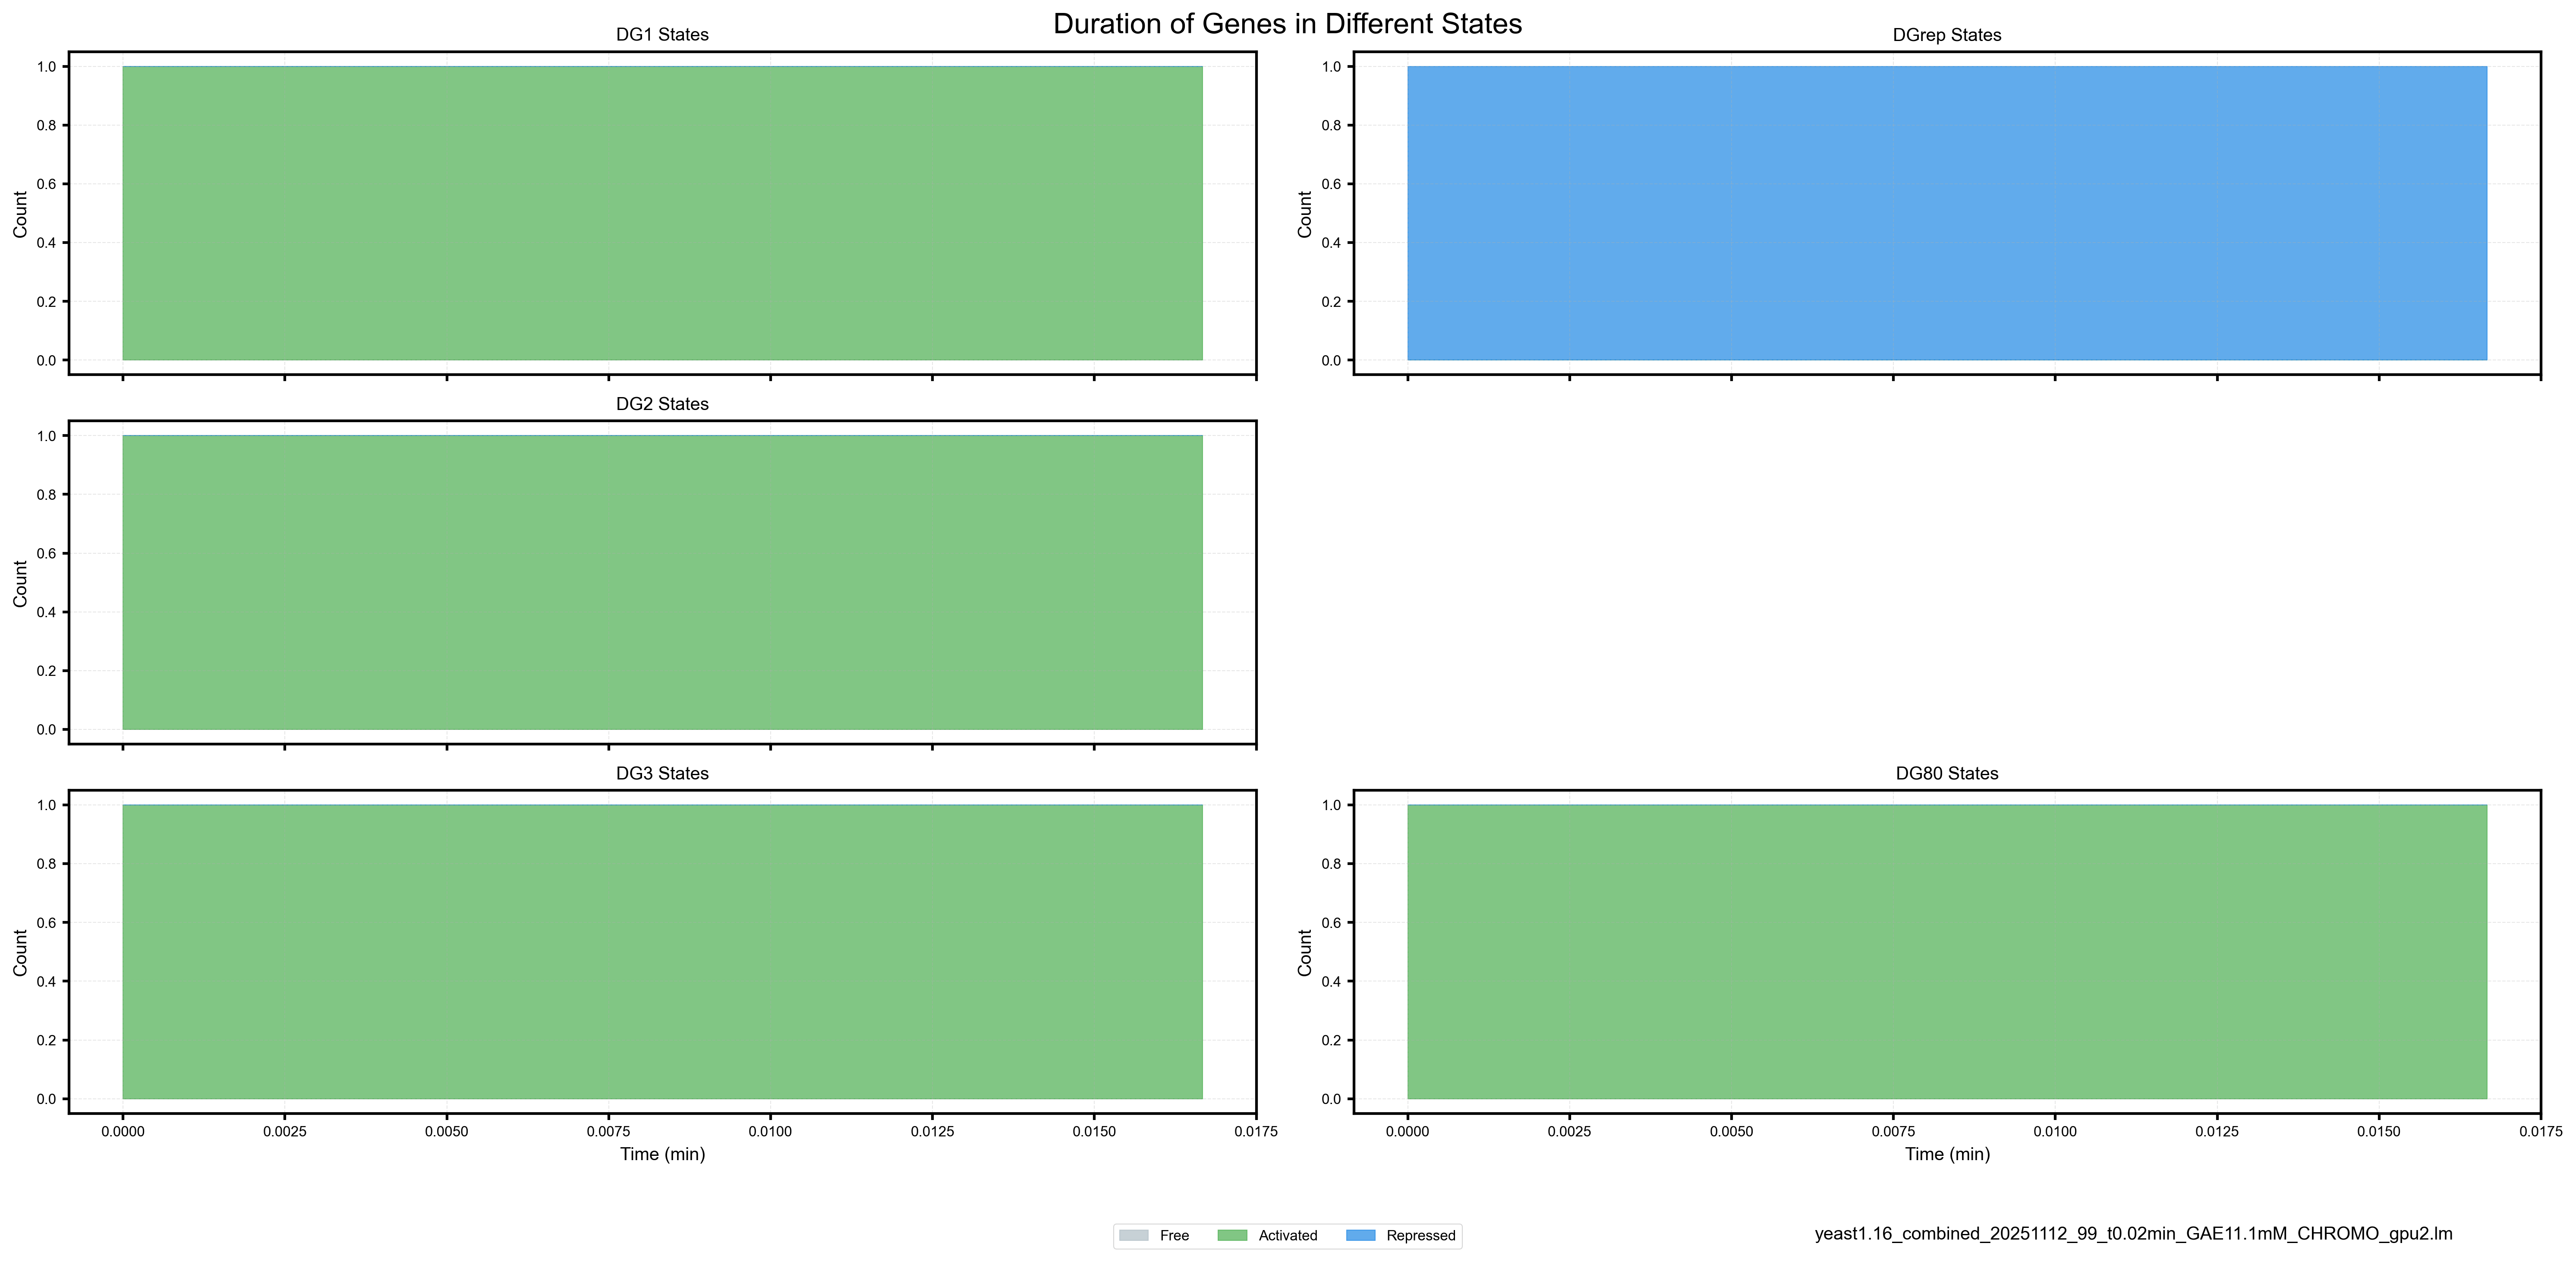

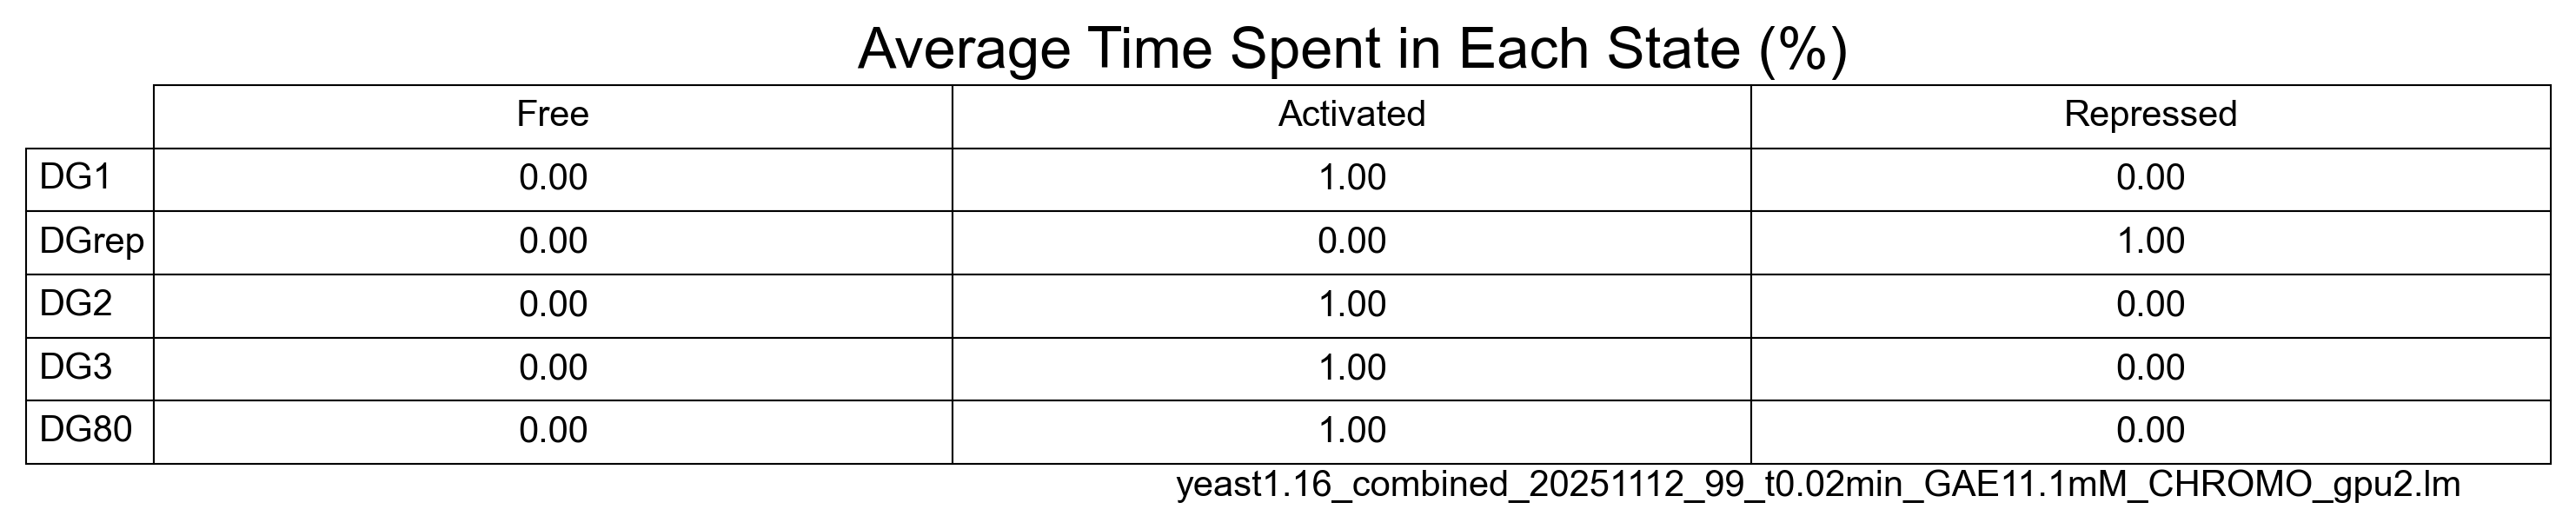

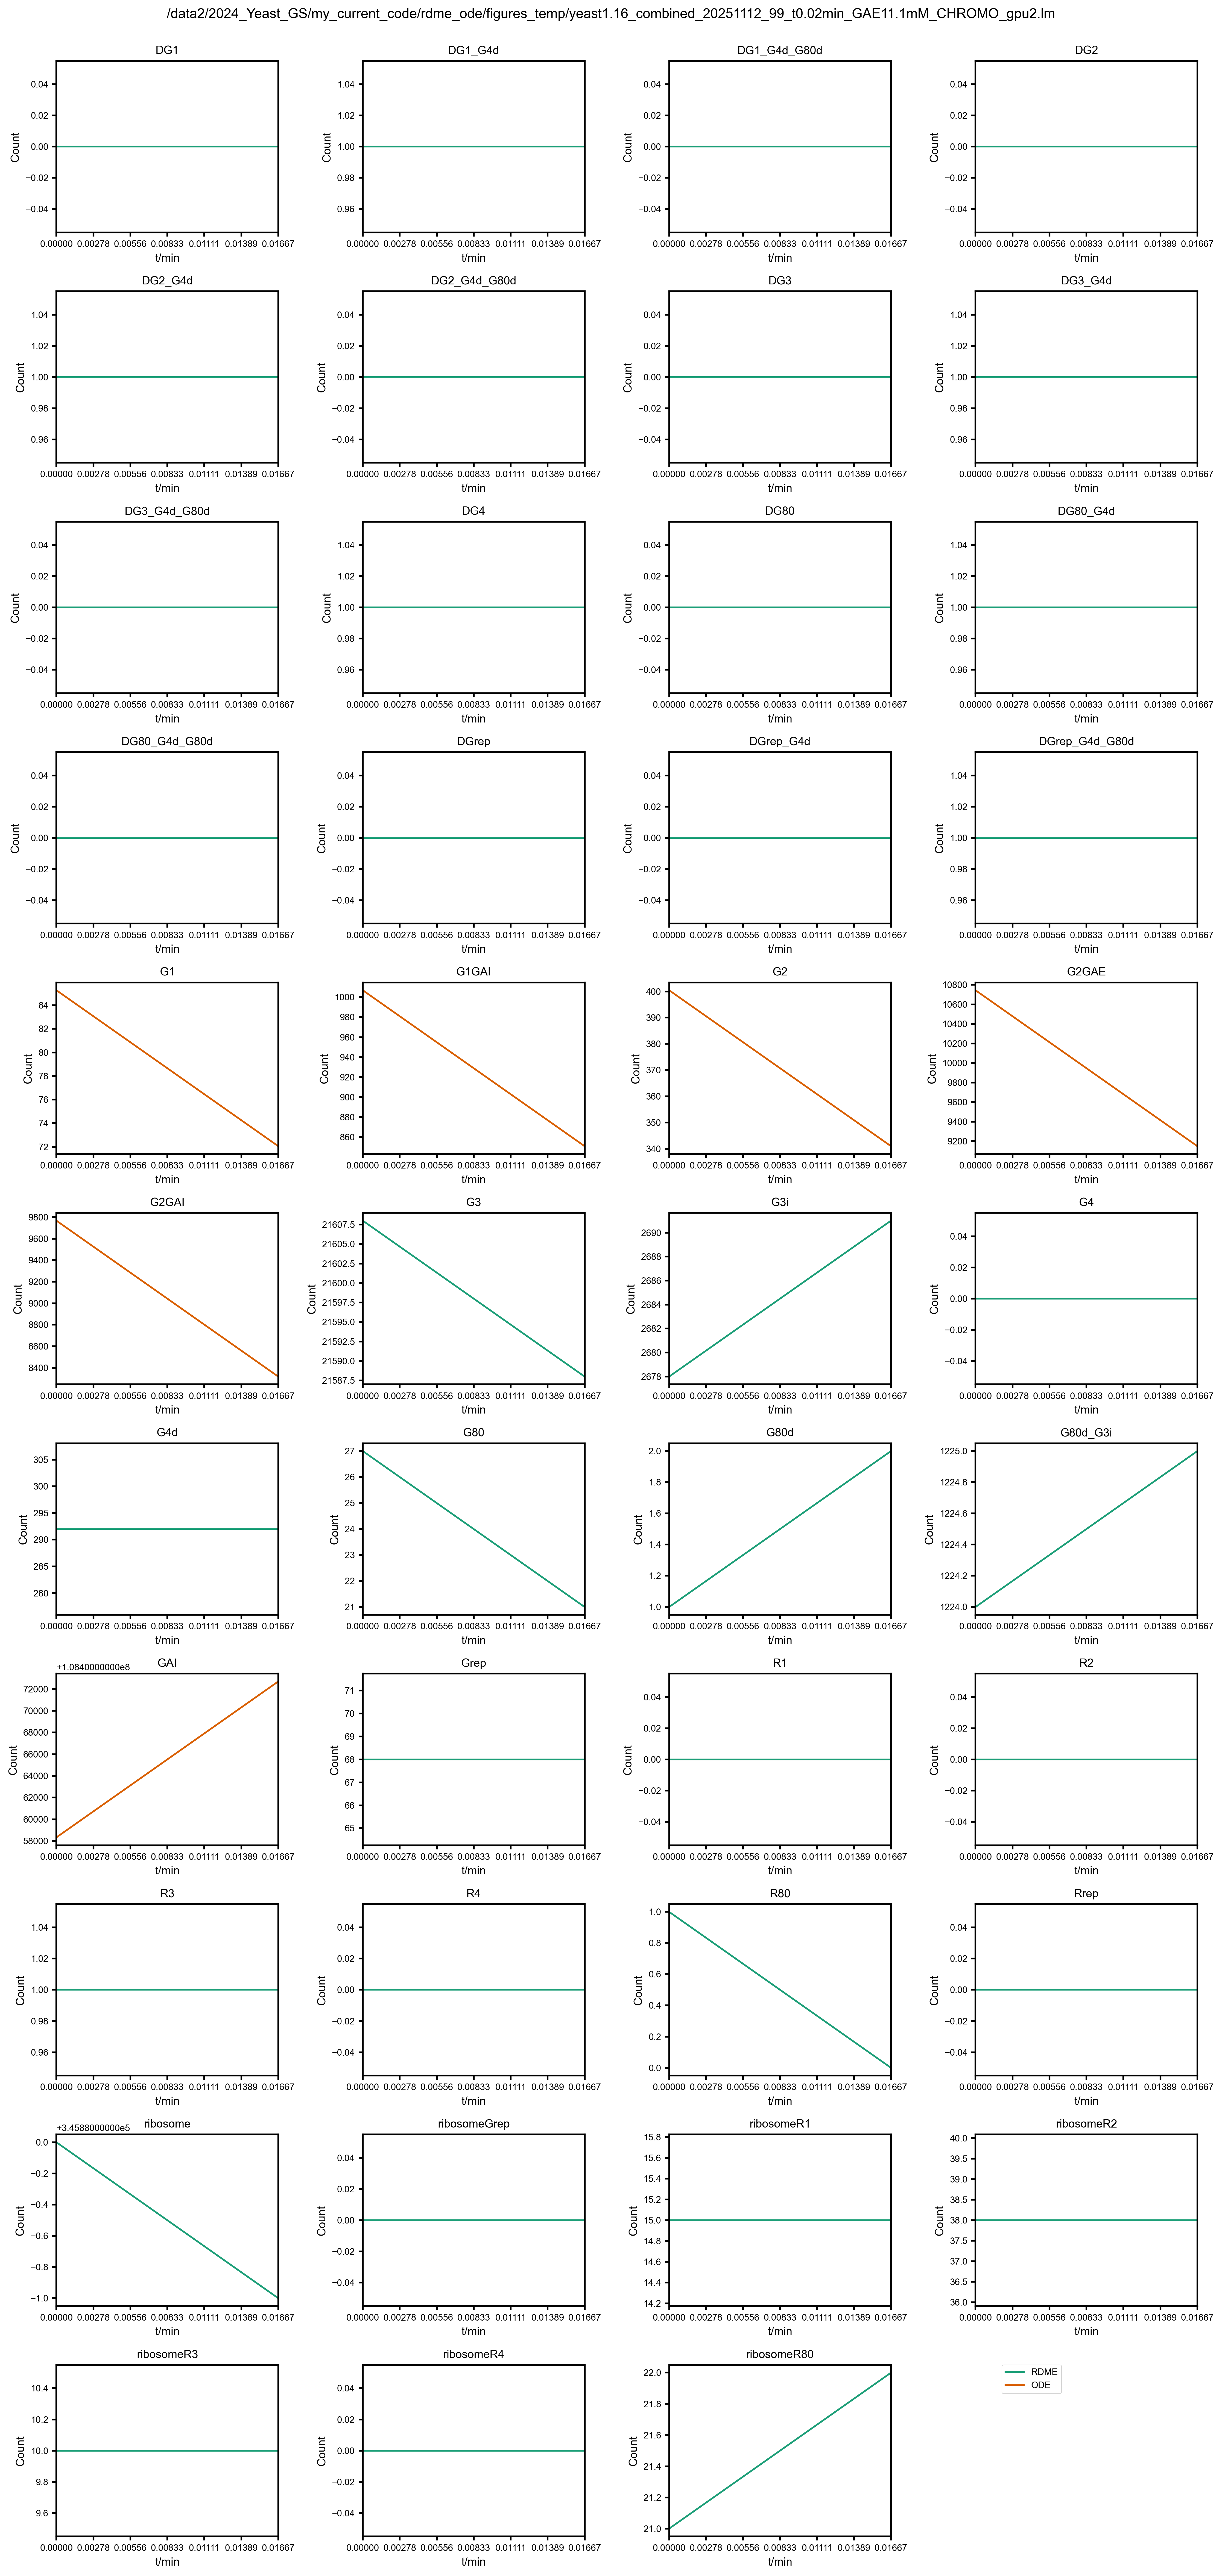

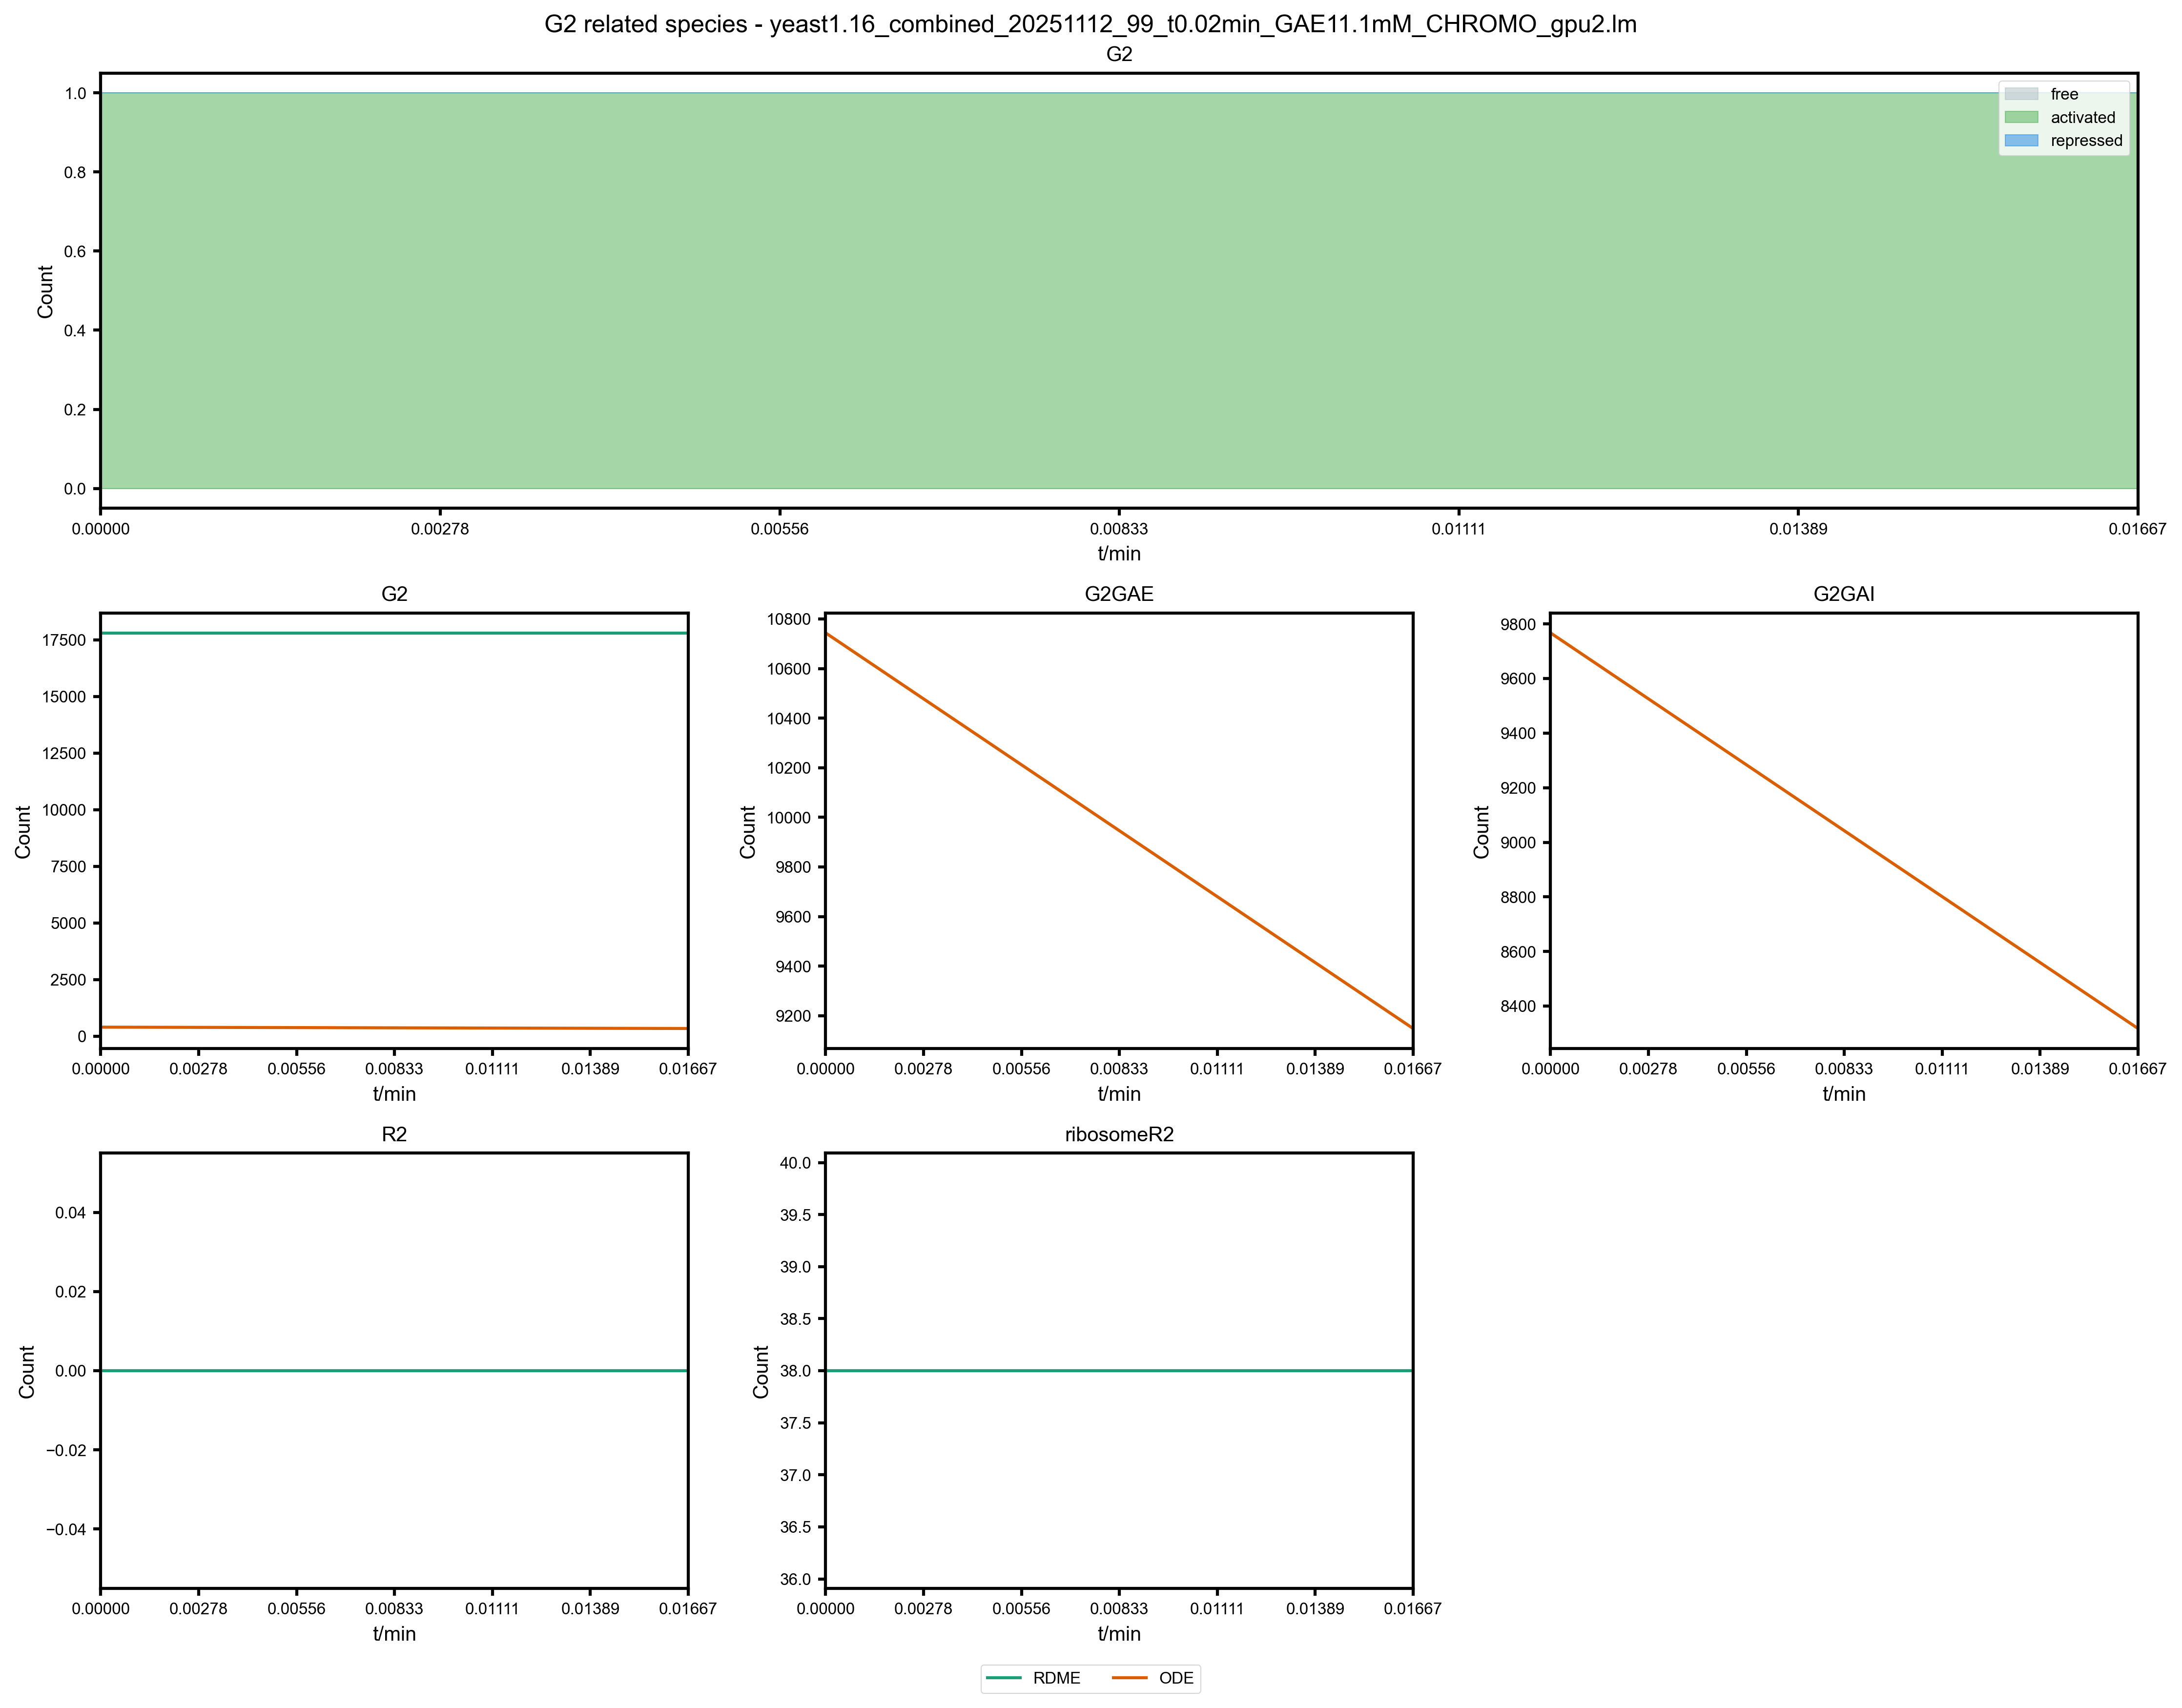

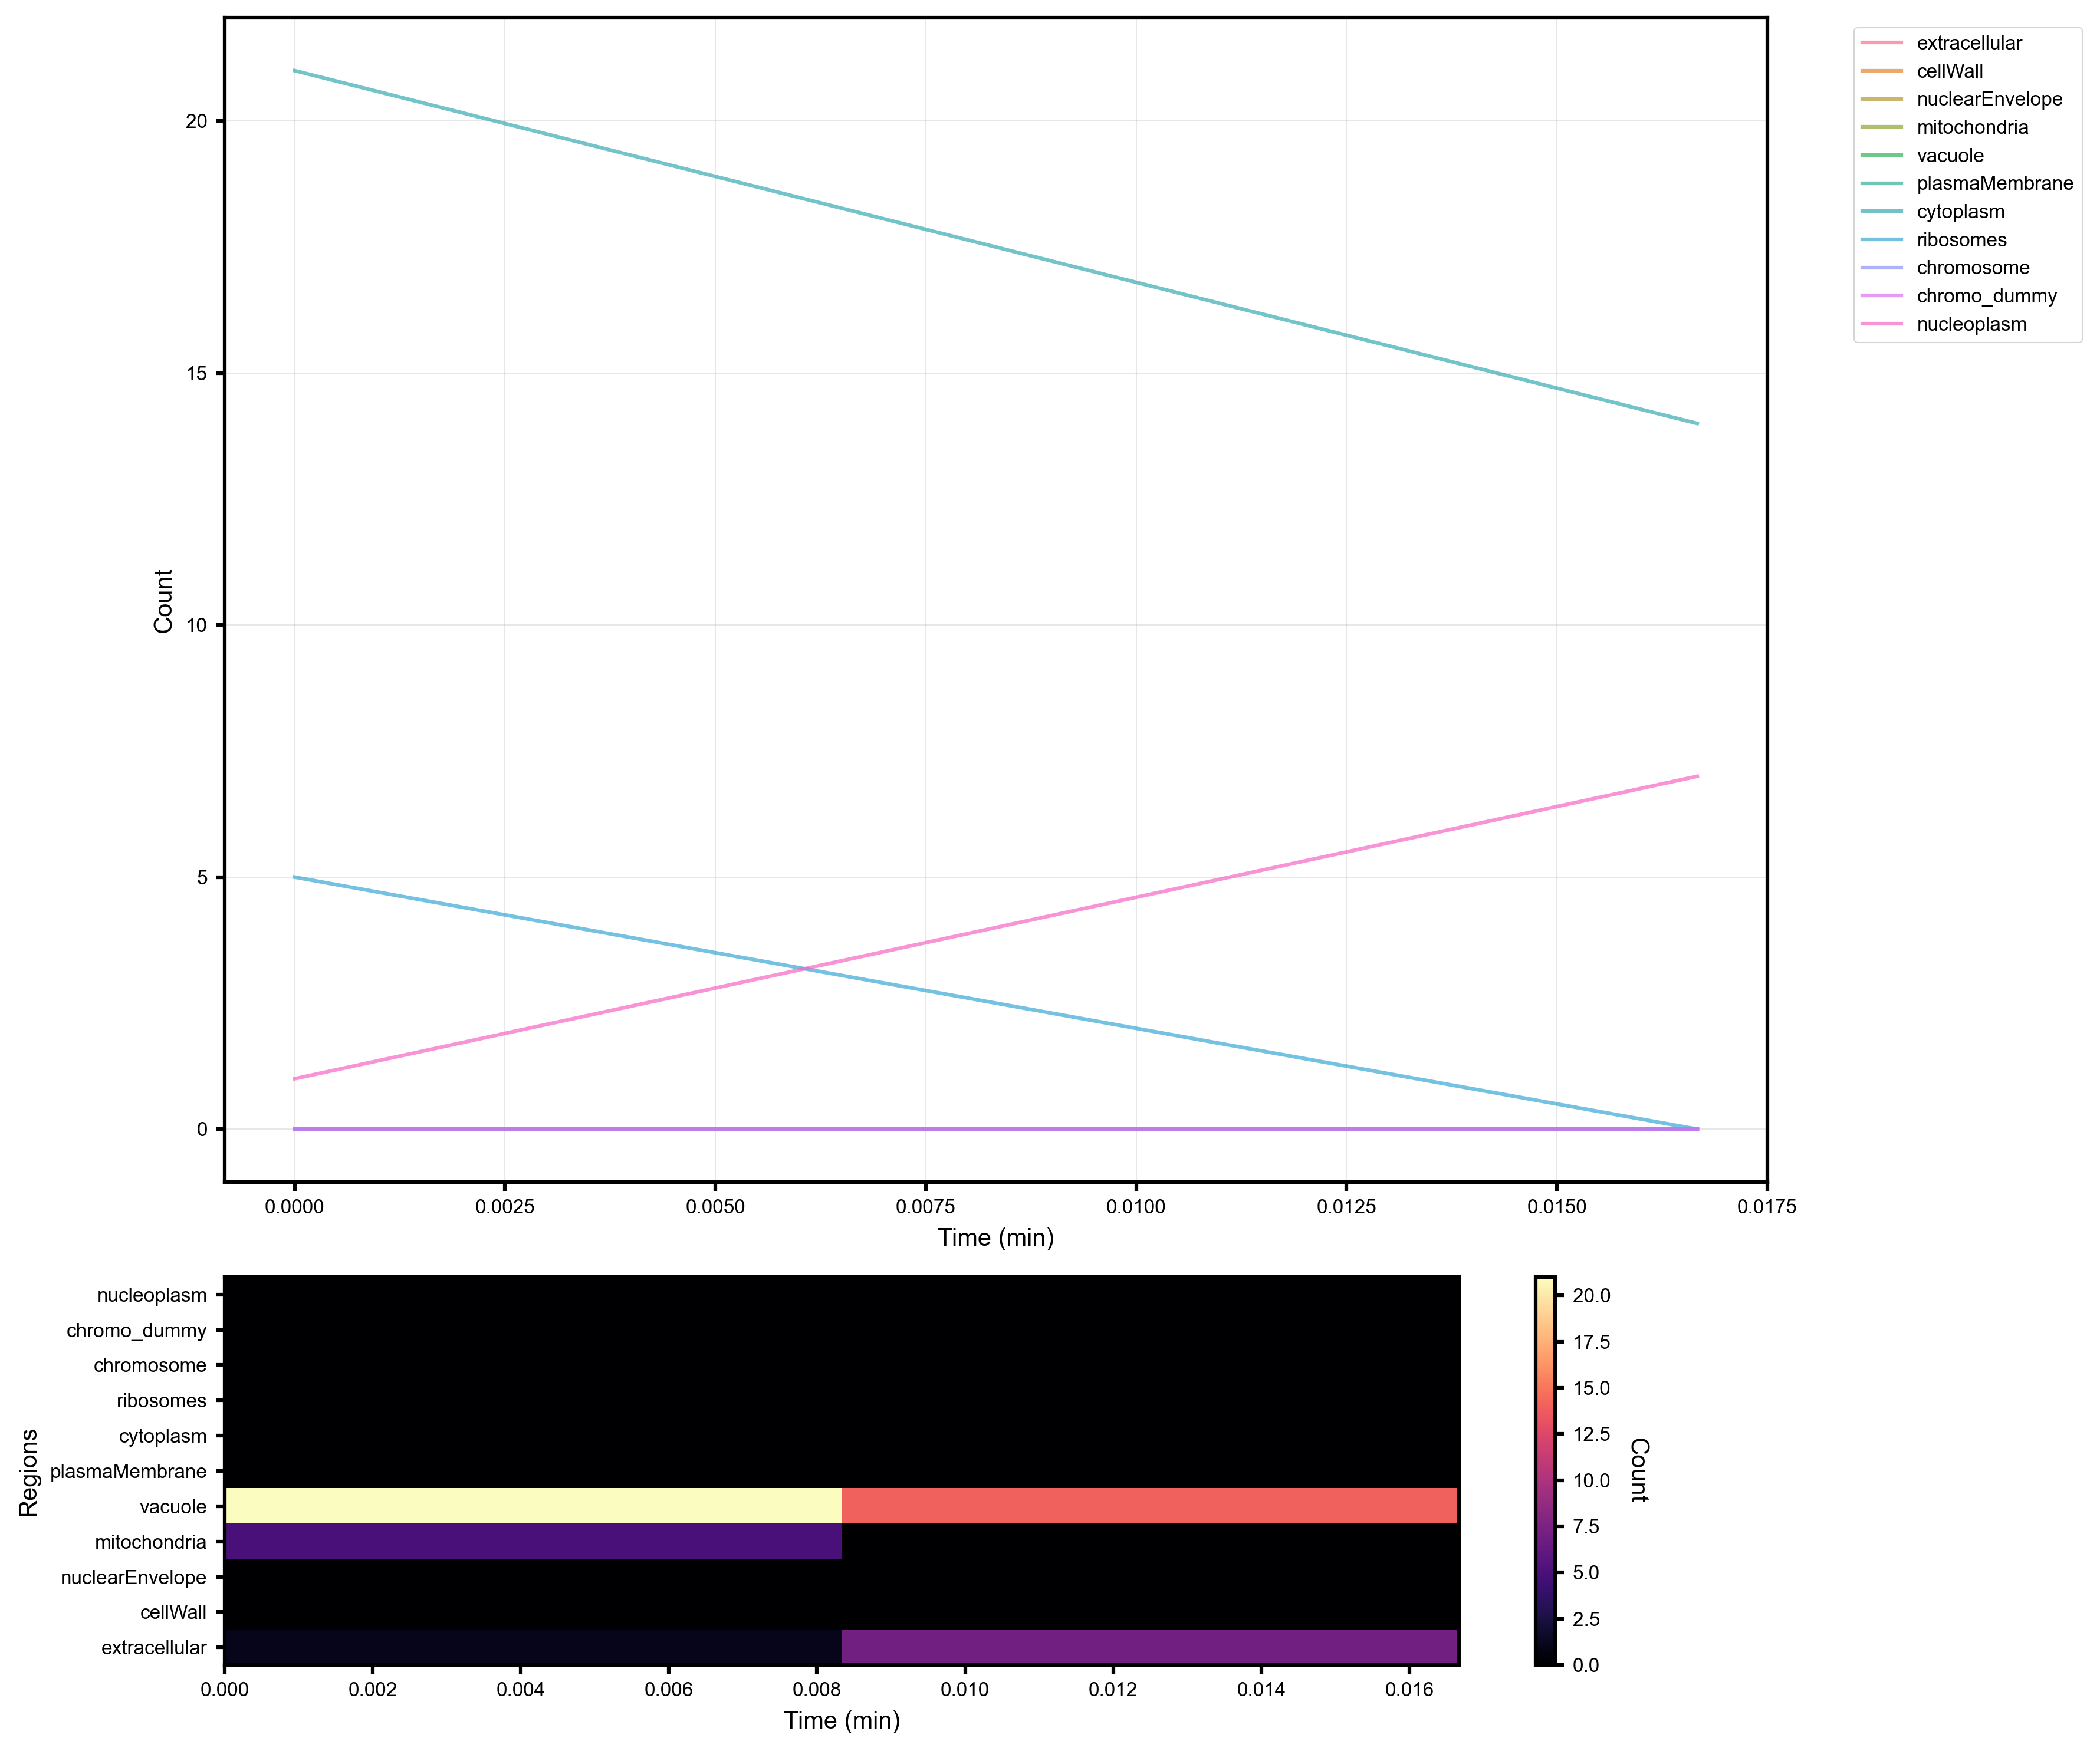

Processing files: 100%|██████████| 1/1 [00:20<00:00, 20.78s/file]


In [4]:

# traj_fname = "/data2/2024_Yeast_GS/code_sif/sim/yeast-dummy-mrna.lm"
# traj = RDMEFile(traj_fname)
# odeTraj = pickle.load(open(traj_fname + "_ode.pkl", "rb"))

# This is the original data 
# traj_dir = "/data2/2024_Yeast_GS/code_sif/sim/"
# traj_file = "yeast-dummy-mrna.lm"
# traj_suff = ".pkl"
# odeTraj = pickle.load(open(traj_dir+traj_file+ traj_suff, "rb"))
## this is original 
## this file is generated by sciprt getStats.py
# rdmePerCompartment = pickle.load(open(traj_dir+"pstats-dummy-mrna.pkl", "rb"))

traj_dir = "/data2/2024_Yeast_GS/my_current_code/rdme_ode"
fig_dir = os.path.join(traj_dir, 'figures_temp/')
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
matching_files = [f for f in os.listdir(traj_dir) if f.startswith('yeast1.16') and f.endswith('.lm')]

# matching_files = ['yeast_20240823_3_t60.0minGAE11.1mM.lm']

# traj_file = "yeast_1.12_20240911_0_t60.0minGAE11.1mM.lm"
traj_suff = "_ode.jsonl"
# traj_suff = "_ode.pkl"
for traj_file in tqdm(matching_files, desc="Processing files", unit="file"):
    traj, odeTraj,region_traj = get_traj(traj_dir, traj_file, traj_suff, region_suff='_region.jsonl')
    # print(region_traj['ts'])
    # # read all species data
    rdmeTs, rdmeYs, odeTs, odeYs,regionTs, regionYs = get_data_for_plot(traj, odeTraj, region_traj, sparse_factor = 1)    # gene expression states
    plot_gene_states_duration(traj_file, fig_dir, rdmeTs, rdmeYs)
    # create a table for the average time spent in each state
    plot_gene_states_duration_table(traj_file, fig_dir, rdmeTs, rdmeYs)
    # all species plot
    plot_all_species(traj_file, fig_dir, rdmeTs, rdmeYs, odeTs, odeYs)
    #tailored species plot 
    plot_tailored_species(traj,traj_file, fig_dir, rdmeTs, rdmeYs, odeTs, odeYs)
    # Filter names to include only those with 'G2' or 'R2'
    interested_species ='G2'
    plot_species_specific(interested_species, traj_file, fig_dir, rdmeTs, rdmeYs, odeTs, odeYs)

    # plot species by region
    interested_species = 'G80'
    interested_regions = region_traj['regions']
    plot_species_by_region(interested_species, interested_regions, traj_file, fig_dir, regionTs, regionYs, region_traj['regions'], region_traj['names'])


## Region specific plot

In [4]:


if traj_suff.endswith('pkl'):
    print("This is not supported, we only support jsonl format right now")
elif traj_suff.endswith('jsonl'):
    region_file = traj_dir + traj_file + "_region.jsonl"
    print(region_file)
    region_data = read_jsonl(region_file)
    
else:
    print("This is not supported, we only support jsonl format right now")

/data2/2024_Yeast_GS/my_current_code/rdme_ode_results/20250922_CHROMO_RNATracker_NewDyeast1.16_combined_20250919_621_t60.0min_GAE11.1mM_ER_CHROMOchromo_ER_rnatracker_gpu4.lm_region.jsonl


FileNotFoundError: [Errno 2] No such file or directory: '/data2/2024_Yeast_GS/my_current_code/rdme_ode_results/20250922_CHROMO_RNATracker_NewDyeast1.16_combined_20250919_621_t60.0min_GAE11.1mM_ER_CHROMOchromo_ER_rnatracker_gpu4.lm_region.jsonl'

In [ ]:
# Print all keys from the first item in region_data, excluding 'time'
for key in region_data[0].keys():
    if 'time' not in key.lower():
        print(key)
        
        

# Example usage:
species_to_plot = ['G2', 'G80', 'DG2_G4d']  # Add or remove species as needed
plot_species_by_region(traj_file, traj_dir, region_data, species_to_plot)

## Depreciated

In [ ]:
# def boxcar(ts,ys,factor):
#     ts2 = np.zeros(ts.size//factor)
#     ys2 = np.zeros(ts.size//factor)
#     n = factor*(ts.size//factor)
#     for i in range(factor):
#         ts2 += ts[i:n:factor]
#         ys2 += ys[i:n:factor]
#     return ts2/factor, ys2/factor

In [ ]:
# g80dimers = ['DG2_G4d_G80d', 'G80d', 'RGrep', 'DGrep_G4d_G80d', 'DG80_G4d_G80d', 'DG3_G4d_G80d', 'G80G3i',  'DG1_G4d_G80d']
# g80monomers = ['G80']

In [ ]:
# nucNs = (sum(rdmePerCompartment[x]['nucleoplasm']['number'] for x in g80dimers)
#           + 0.5*sum(rdmePerCompartment[x]['nucleoplasm']['number'] for x in g80monomers))
# allNs = (sum(rdmeYs[x] for x in g80dimers) + 0.5*sum(rdmeYs[x] for x in g80monomers))

# nucCs = (sum(rdmePerCompartment[x]['nucleoplasm']['conc'] for x in g80dimers)
#           + 0.5*sum(rdmePerCompartment[x]['nucleoplasm']['conc'] for x in g80monomers))
# cytCs = (sum(rdmePerCompartment[x]['cytoplasm']['conc'] for x in g80dimers)
#           + 0.5*sum(rdmePerCompartment[x]['cytoplasm']['conc'] for x in g80monomers))

# deci = 200
# deciTs, nuclearFraction = boxcar(rdmeTs, nucNs/allNs, deci)
# deciTs, nuclearConc = boxcar(rdmeTs, nucCs, deci)
# deciTs, cytoConc = boxcar(rdmeTs, cytCs, deci)

# nuclearConc = nuclearConc/1e-9
# cytoConc = cytoConc/1e-9

In [ ]:
# fig, ax = plt.subplots(figsize=(5,3.5))

# ax.plot(deciTs[:60], nuclearConc[:60], label="Nucleus")
# ax.plot(deciTs[:60], cytoConc[:60], label="Cytoplasm")
# # ax.set(xlim=(deciTs[0], deciTs[-1]), xlabel="t(min)", ylabel="nM")
# ax.set(xlim=(deciTs[0], 60), xlabel="t(min)", ylabel="nM")
# ax.legend()
# ax.title.set_text("Concentration of G$_{80}$ dimer")
# # add annotation to the plot

# # fig.tight_layout()
# plt.savefig('G80_concentration.png',dpi=300,bbox_inches='tight')

In [ ]:
# # fig, ax = plt.subplots(figsize=(5,3.5))
# fig, ax = plt.subplots()
# ax.plot(deciTs, nuclearFraction, label="$n_{\mathrm{G80}}$ nuc./total")
# ax.plot(odeTs, 1e3*odeYs["GAI"]/NAV/11.1, label="[Gal] cyt./ext.")
# # ax.set(xlim=(deciTs[0], deciTs[-1]), ylim=(0,0.4), xlabel="t/min", ylabel="Fraction")
# ax.set(xlim=(deciTs[0], 60), ylim=(0,0.4), xlabel="t/min", ylabel="Fraction")
# ax.legend()
# ax.title.set_text("Fraction of G$_{80}$ in nucleus, [Gal] in cytoplasm/extra-cellular")
# # fig.tight_layout()
# fig.savefig('fraction.png',dpi=300,bbox_inches='tight')

In [ ]:
# fig, ax = plt.subplots(figsize=(0.8*6,0.8*3.5))
# ax2 = ax.twinx()
# #ax.plot(deciTs, nuclearFraction, label="$n_{\mathrm{G80}}$ nuc./total")

# nmemg2 = rdmePerCompartment['G2']['plasmaMembrane']['number']
# _, nmemg2 = boxcar(rdmeTs, nmemg2, deci)
# colors = sns.color_palette()

# g2plot = ax.plot(deciTs, nmemg2/1e3, c=colors[0])[0]
# gaiplot = ax2.plot(odeTs, 1e3*odeYs["GAI"]/NAV, c=colors[1])[0]
# ax.set(xlim=(deciTs[0], deciTs[-1]), xlabel="t/min")
# ax2.set(xlim=(deciTs[0], deciTs[-1]), xlabel="t/min")
# ax2.set(ylabel=r"[Gal]$_{\mathrm{int}}$/mM", ylim=(0,6))
# ax.set(ylabel=r"n$_{\mathrm{G2}}$/$10^{3}$", ylim=(0,13))
# ax.legend([g2plot,gaiplot], ["G2", "Internal galactose"])
# fig.tight_layout()